In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
from collections import defaultdict
from itertools import combinations

In [2]:
currdf = pd.read_csv('cbb25.csv')
pastdf = pd.read_csv('pastCBB.csv')

pastdf['Win%'] = pastdf['W'] / pastdf['G'] #Win%
currdf['Win%'] = currdf['W'] / currdf['G'] #Win%

In [3]:
def pca(X, num_components):
    #PCA dimension reduction
    X_centered = X - X.mean(axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    sorted_idx = np.argsort(eigenvalues)[::-1]
    top_eigenvectors = eigenvectors[:, sorted_idx[:num_components]]
    X_reduced = np.dot(X_centered, top_eigenvectors)
    return X_reduced, top_eigenvectors

def kmeans(X, k, max_iters=100):
    n_samples, n_features = X.shape
    # Randomly choose initial centers
    np.random.seed(42)
    centers = X[np.random.choice(n_samples, k, replace=False)]

    for _ in range(max_iters):
        # Assign clusters
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        clusters = np.argmin(distances, axis=1)

        # Update centers
        new_centers = np.array([X[clusters == i].mean(axis=0) for i in range(k)])

        # Check convergence
        if np.allclose(centers, new_centers):
            break
        centers = new_centers

    return centers, clusters

def gaussian_pdf(x, mean, cov):
    n = x.shape[0]
    cov_det = np.linalg.det(cov)
    cov_inv = np.linalg.inv(cov)
    norm_const = 1.0 / (np.power((2*np.pi), n/2) * np.sqrt(cov_det))
    x_mu = x - mean
    result = np.exp(-0.5 * np.dot(np.dot(x_mu.T, cov_inv), x_mu))
    return norm_const * result

def gmm(X, k, centers, max_iters=100):
    n_samples, n_features = X.shape
    means = centers
    covariances = np.array([np.eye(n_features) for _ in range(k)])
    weights = np.ones(k) / k

    for _ in range(max_iters):
        # E-step
        responsibilities = np.zeros((n_samples, k))
        for i in range(k):
            for j in range(n_samples):
                responsibilities[j, i] = weights[i] * gaussian_pdf(X[j], means[i], covariances[i])
        
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step
        Nk = responsibilities.sum(axis=0)
        for i in range(k):
            means[i] = (responsibilities[:, i][:, np.newaxis] * X).sum(axis=0) / Nk[i]
            diff = X - means[i]
            covariances[i] = (responsibilities[:, i][:, np.newaxis, np.newaxis] *
                              np.matmul(diff[:, :, np.newaxis], diff[:, np.newaxis, :])).sum(axis=0) / Nk[i]
            weights[i] = Nk[i] / n_samples

    return means, covariances, weights, responsibilities


def explained_variance(X):
    X_centered = X - X.mean(axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    sorted_eigenvalues = np.sort(eigenvalues)[::-1]
    total_variance = np.sum(sorted_eigenvalues)
    explained_ratios = sorted_eigenvalues / total_variance
    return explained_ratios

def plot_scree(explained_ratios):
    cumulative_variance = np.cumsum(explained_ratios)
    
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
    plt.title('Scree Plot (Elbow Method for PCA)')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.grid(True)
    plt.show()

def normalize(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X_norm = (X - mean) / std
    return X_norm, mean, std

def kmeans_inertia(X, max_k=10):
    inertias = []
    
    for k in range(1, max_k + 1):
        centers, clusters = kmeans(X, k=k)
        # Compute inertia (sum of squared distances to nearest center)
        inertia = 0
        for i in range(len(X)):
            center = centers[clusters[i]]
            inertia += np.sum((X[i] - center) ** 2)
        inertias.append(inertia)
    
    return inertias

def plot_kmeans_elbow(inertias):
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(inertias) + 1), inertias, marker='o')
    plt.title('KMeans Elbow Plot (Choosing number of clusters)')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Sum of Squared Distances)')
    plt.grid(True)
    plt.show()

def plot_clusters_2D(X_pca, cluster_assignments, k):
    plt.figure(figsize=(8,6))
    for cluster_id in range(k):
        cluster_points = X_pca[cluster_assignments == cluster_id]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}")
    
    plt.title('Cluster Visualization (First 2 PCA Components)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_clusters_3D(X_pca, cluster_assignments, k):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    
    for cluster_id in range(k):
        cluster_points = X_pca[cluster_assignments == cluster_id]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], label=f"Cluster {cluster_id}")
    
    ax.set_title('Cluster Visualization (First 3 PCA Components)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.legend()
    plt.show()

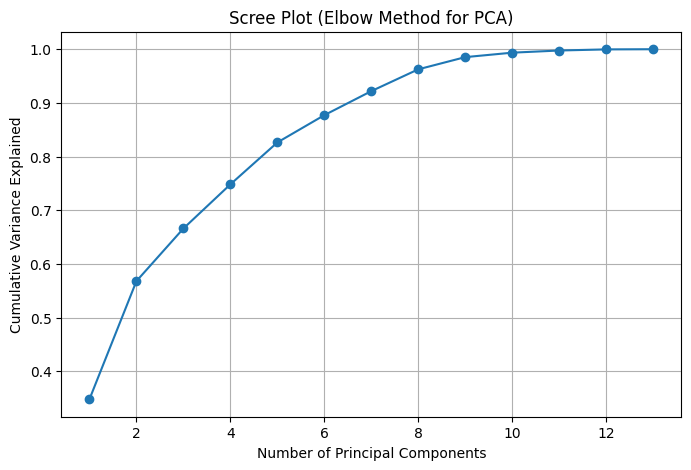

In [4]:
numeric_features = [
    'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 
    'TOR', 'ORB', 'DRB', '3P%', '2P%', 'Win%', 'WAB', 'ADJ_T'
]

X_weighted = pastdf[numeric_features].copy()
X_weighted25 = currdf[numeric_features].copy() #Weighting certain stats more due to importance

X_weighted['BARTHAG'] *= 3.0
X_weighted['ADJOE'] *= 2.0
X_weighted['ADJDE'] *= 2.0
X_weighted['EFG_O'] *= 1.5
X_weighted['EFG_D'] *= 1.5
X_weighted['Win%'] *= 1.5
X_weighted['3P%'] *= 1.2
X_weighted['2P%'] *= 1.2
X_weighted['ORB'] *= 1.2
X_weighted['DRB'] *= 1.2
X_weighted['TOR'] *= 1.0
X_weighted['WAB'] *= 2.0
X_weighted['ADJ_T'] *= 0.7

X_weighted25['BARTHAG'] *= 3.0
X_weighted25['ADJOE'] *= 2.0
X_weighted25['ADJDE'] *= 2.0
X_weighted25['EFG_O'] *= 1.5
X_weighted25['EFG_D'] *= 1.5
X_weighted25['Win%'] *= 1.5
X_weighted25['3P%'] *= 1.2
X_weighted25['2P%'] *= 1.2
X_weighted25['ORB'] *= 1.2
X_weighted25['DRB'] *= 1.2
X_weighted25['TOR'] *= 1.0
X_weighted25['WAB'] *= 2.0
X_weighted25['ADJ_T'] *= 0.7

X = X_weighted.values
X25 = X_weighted25.values

X_norm, mean, std = normalize(X)

X25_norm = (X25 - mean) / std #Norm using past data mean and standard deviation



explained_ratios = explained_variance(X_norm)
plot_scree(explained_ratios) # We want .9 varaince explained

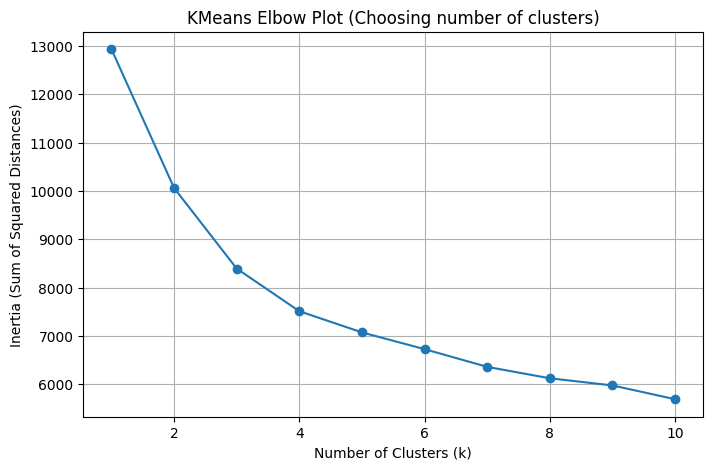

In [5]:
X_pca7, eigenvectors = pca(X_norm, num_components=7) #7 components 

X_pca_cbb25 = np.dot(X25_norm, eigenvectors) 

inertias = kmeans_inertia(X_pca7, max_k=10)
plot_kmeans_elbow(inertias)

In [6]:
centers, clusters = kmeans(X_pca7, k=10) #Using 10 clusters

means, covariances, weights, responsibilities = gmm(X_pca7, k=10, centers=centers)

team_assignments = np.argmax(responsibilities, axis=1)

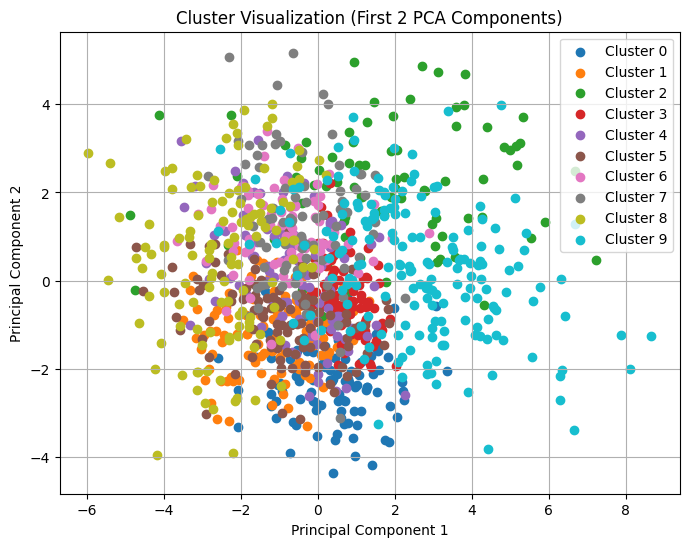

In [7]:
plot_clusters_2D(X_pca7, team_assignments, k=10)

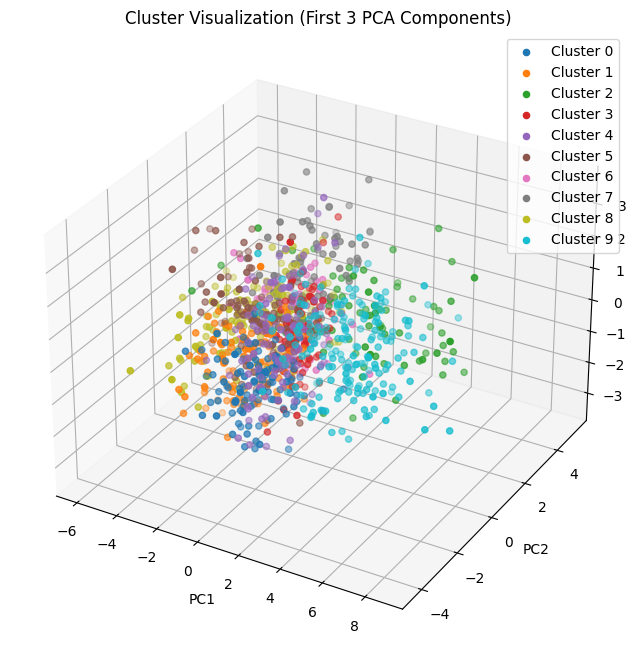

In [8]:
plot_clusters_3D(X_pca7, team_assignments, k=10)

In [9]:
team_df = pastdf.copy()
team_df['Assigned_Cluster'] = team_assignments

for cluster_id in range(responsibilities.shape[1]):
    team_df[f'Cluster_{cluster_id}_Prob'] = responsibilities[:, cluster_id]

cluster_summary = team_df.groupby('Assigned_Cluster').agg({
    'Win%': ['mean', 'count'],
    'Result': ['mean', 'count']
}).sort_values(('Win%', 'mean'), ascending=False)

print(cluster_summary)

                      Win%           Result      
                      mean count       mean count
Assigned_Cluster                                 
8                 0.783503   126  25.039683   126
5                 0.765660   112  38.098214   112
7                 0.763276    82  54.536585    82
1                 0.741619   112  29.339286   112
4                 0.723621   111  42.486486   111
6                 0.704667    81  42.777778    81
0                 0.689784   111  39.720721   111
9                 0.662874   182  60.000000   182
2                 0.660928    79  57.189873    79
3                 0.618446    83  48.289157    83


Cluster 0: Lower win rate but round fo 32 possible

Cluster 1: Mid win rate and go pretty far in the tournament

Cluster 2: Bad win rate and eliminated early

Cluster 3: Bad win rate but chance to make an upset in the first round

Cluster 4: Likely round of 32, mid win rate

Cluster 5: High win rate but not likely winners (Sweet 16)

Cluster 6: Similar to Cluster 4

Cluster 7: High win rate but bad results

Cluster 8: Likely winners, best teams and best results

Cluster 9: Round of 64 exits

In [10]:
n_samples = X_pca_cbb25.shape[0]
k = means.shape[0]  # Number of clusters

responsibilities_cbb25 = np.zeros((n_samples, k))

for i in range(k):
    for j in range(n_samples):
        responsibilities_cbb25[j, i] = weights[i] * gaussian_pdf(X_pca_cbb25[j], means[i], covariances[i])

responsibilities_cbb25 /= responsibilities_cbb25.sum(axis=1, keepdims=True)

team_assignments_cbb25 = np.argmax(responsibilities_cbb25, axis=1)

In [11]:
team_names = currdf['Team'].values  

responsibility_df = pd.DataFrame(responsibilities_cbb25, columns=[f'Cluster_{i}_Prob' for i in range(responsibilities_cbb25.shape[1])])
responsibility_df['Team'] = team_names
responsibility_df['Assigned_Cluster'] = team_assignments_cbb25

cols = ['Team', 'Assigned_Cluster'] + [f'Cluster_{i}_Prob' for i in range(responsibilities_cbb25.shape[1])]
responsibility_df = responsibility_df[cols]

In [12]:
def compare_teams(team1_name, team2_name, responsibility_df, cluster_count=8):
    # Find the rows for each team
    team1_row = responsibility_df[responsibility_df['Team'] == team1_name]
    team2_row = responsibility_df[responsibility_df['Team'] == team2_name]
    
    if team1_row.empty or team2_row.empty:
        print("One or both team names not found.")
        return
    
    # Print basic info
    print(f"Team 1: {team1_name}")
    # Comment out this line:
    # print(f"  Seed: {team1_row['Seed'].values[0]}")
    print(f"  Assigned Cluster: {team1_row['Assigned_Cluster'].values[0]}")
    for i in range(cluster_count):
        prob = team1_row[f'Cluster_{i}_Prob'].values[0]
        print(f"    Cluster {i} Probability: {prob:.4f}")
        
    print("\n-------------------------\n")
    
    print(f"Team 2: {team2_name}")
    # Comment out this line too:
    # print(f"  Seed: {team2_row['Seed'].values[0]}")
    print(f"  Assigned Cluster: {team2_row['Assigned_Cluster'].values[0]}")
    for i in range(cluster_count):
        prob = team2_row[f'Cluster_{i}_Prob'].values[0]
        print(f"    Cluster {i} Probability: {prob:.4f}")


In [13]:
compare_teams('Houston', 'Florida', responsibility_df, 10) 

Team 1: Houston
  Assigned Cluster: 8
    Cluster 0 Probability: 0.0034
    Cluster 1 Probability: 0.0000
    Cluster 2 Probability: 0.0000
    Cluster 3 Probability: 0.0000
    Cluster 4 Probability: 0.0000
    Cluster 5 Probability: 0.0000
    Cluster 6 Probability: 0.0000
    Cluster 7 Probability: 0.0001
    Cluster 8 Probability: 0.9963
    Cluster 9 Probability: 0.0001

-------------------------

Team 2: Florida
  Assigned Cluster: 8
    Cluster 0 Probability: 0.0000
    Cluster 1 Probability: 0.0244
    Cluster 2 Probability: 0.0001
    Cluster 3 Probability: 0.0000
    Cluster 4 Probability: 0.0290
    Cluster 5 Probability: 0.0000
    Cluster 6 Probability: 0.0000
    Cluster 7 Probability: 0.0000
    Cluster 8 Probability: 0.9417
    Cluster 9 Probability: 0.0049


I went through each matchup and made conclusions interpreting the data while also taking the itemset analysis into consideration. 

![Screen%20Shot%202023-11-27%20at%204.29.53%20PM.png](IMG_0061.png)